# Netflix Catalog - Exploratory Data Analysis 2011-2020

**Phạm vi:** title được thêm vào Netflix từ 01/01/2011 đến 31/12/2020.  
**Timeline chính:** `date_added`, không phải `release_year`.  
**Quy tắc đếm:** số title luôn dùng `nunique(show_id)` để tránh đếm lặp.

## 1 Đọc dữ liệu

Notebook dùng dữ liệu đã được làm sạch và chuẩn hóa trong `data/normalized`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dùng nền trắng thống nhất cho toàn bộ figure và vùng vẽ.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.linewidth": 1.0
})

# Khi chạy Jupyter từ thư mục gốc project, đường dẫn đầu tiên sẽ được dùng.
# Nếu mở notebook từ thư mục notebook, chương trình tự dùng đường dẫn thứ hai.
DATA_DIR = Path("data/normalized")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data/normalized")

titles = pd.read_csv(DATA_DIR / "dim_title.csv")
genres = pd.read_csv(DATA_DIR / "bridge_genre.csv")
countries = pd.read_csv(DATA_DIR / "bridge_country.csv")
monthly = pd.read_csv(DATA_DIR / "fact_monthly_addition.csv")

# Chuyển date_added sang kiểu ngày và tạo trường năm.
titles["date_added"] = pd.to_datetime(titles["date_added"])
titles["added_year"] = titles["date_added"].dt.year

print("Số dòng dim_title:", len(titles))
print("Số dòng bridge_genre:", len(genres))
print("Số dòng bridge_country:", len(countries))
print("Số tháng:", len(monthly))

Số dòng dim_title: 7294
Số dòng bridge_genre: 16026
Số dòng bridge_country: 8528
Số tháng: 120


## 2 Kiểm tra dữ liệu trước khi phân tích

Phần này dùng các phép kiểm tra đơn giản để xác nhận dữ liệu đúng grain và đúng phạm vi.

In [2]:
total_titles = titles["show_id"].nunique()
total_monthly = monthly["monthly_additions"].sum()

print("Số title duy nhất:", total_titles)
print("show_id có duy nhất không:", titles["show_id"].is_unique)
print("Số date_added bị thiếu:", titles["date_added"].isna().sum())
print("Năm nhỏ nhất:", titles["added_year"].min())
print("Năm lớn nhất:", titles["added_year"].max())
print("Tổng monthly additions:", total_monthly)
print("Số tháng trong bảng monthly:", len(monthly))

if total_titles == total_monthly and len(monthly) == 120:
    print("Kết quả: Dữ liệu sẵn sàng cho EDA")
else:
    print("Kết quả: Cần kiểm tra lại dữ liệu")

Số title duy nhất: 7294
show_id có duy nhất không: True
Số date_added bị thiếu: 0
Năm nhỏ nhất: 2011
Năm lớn nhất: 2020
Tổng monthly additions: 7294
Số tháng trong bảng monthly: 120
Kết quả: Dữ liệu sẵn sàng cho EDA


## 3 Tổng quan dữ liệu

`nunique()` trong pandas tương đương với `COUNT DISTINCT` đã học trong chương trường dữ liệu tính toán.

In [3]:
# Đếm số title duy nhất theo loại nội dung.
type_counts = titles.groupby("type")["show_id"].nunique()

movie_count = type_counts["Movie"]
tv_count = type_counts["TV Show"]

movie_share = movie_count / total_titles * 100
tv_share = tv_count / total_titles * 100

overview = pd.DataFrame({
    "Chỉ số": ["Tổng title", "Movie", "TV Show", "Tỷ lệ Movie", "Tỷ lệ TV Show"],
    "Giá trị": [total_titles, movie_count, tv_count, round(movie_share, 1), round(tv_share, 1)]
})

overview

,Chỉ số,Giá trị
0,Tổng title,7294.0
1,Movie,5134.0
2,TV Show,2160.0
3,Tỷ lệ Movie,70.4
4,Tỷ lệ TV Show,29.6


## 4 Phân tích số title được thêm theo năm

**Câu hỏi:** Số title được thêm vào Netflix thay đổi như thế nào trong 2011-2020?  
**Metric:** `COUNT DISTINCT show_id` theo năm của `date_added`.  
**Biểu đồ:** Line chart vì dữ liệu thay đổi theo thời gian.

added_year
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
Name: show_id, dtype: int64


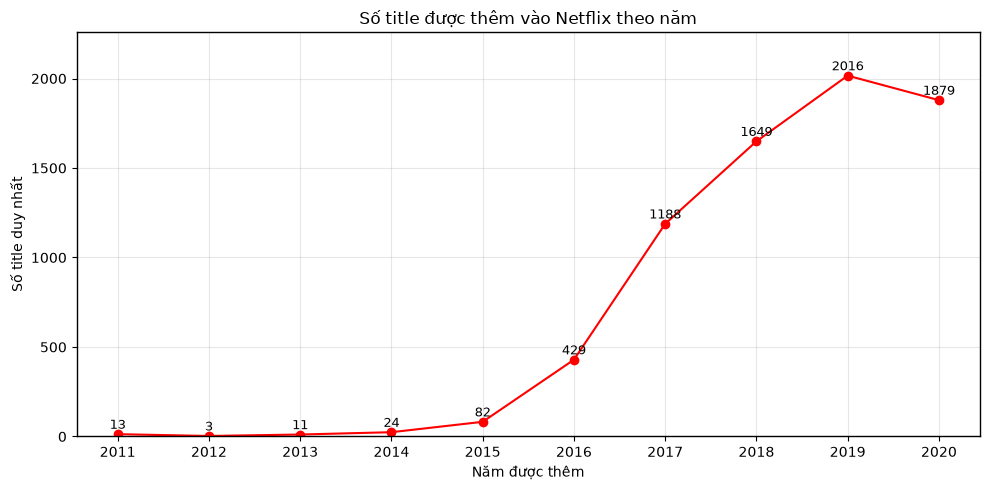

Năm cao nhất: 2019
Số title cao nhất: 2016
Thay đổi 2020 so với 2019: -6.8 %


In [4]:
# Bước 1: Đếm title duy nhất theo năm.
annual = titles.groupby("added_year")["show_id"].nunique()

# Bước 2: Xem bảng kết quả.
print(annual)

# Bước 3: Vẽ biểu đồ đường bằng Matplotlib.
plt.figure(figsize=(10, 5))
plt.plot(annual.index, annual.values, marker="o", color="red")

for year, value in annual.items():
    plt.text(year, value + 30, str(value), ha="center", fontsize=9)

plt.title("Số title được thêm vào Netflix theo năm")
plt.xlabel("Năm được thêm")
plt.ylabel("Số title duy nhất")
plt.xticks(annual.index)
plt.ylim(0, annual.max() * 1.12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bước 4: Tính kết quả nổi bật.
peak_year = annual.idxmax()
peak_value = annual.max()
change_2020 = (annual[2020] - annual[2019]) / annual[2019] * 100

print("Năm cao nhất:", peak_year)
print("Số title cao nhất:", peak_value)
print("Thay đổi 2020 so với 2019:", round(change_2020, 1), "%")

**Observation:** additions tăng mạnh sau năm 2016, đạt đỉnh **2.016 title năm 2019**. Năm 2020 có **1.879 title**, giảm **6,8%** so với năm 2019.  
**Caveat:** đây là số title được thêm vào catalog, không phải năm phát hành, lượt xem hoặc mức độ phổ biến.

## 5 Phân tích Movie và TV Show

**Câu hỏi:** Cơ cấu Movie và TV Show thay đổi như thế nào theo năm?  
**Metric:** số title duy nhất theo `added_year` và `type`, sau đó tính tỷ lệ trong từng năm.  
**Biểu đồ:** 100% stacked bar chart để so sánh tỷ trọng.

Số lượng theo năm:
type        Movie  TV Show
added_year                
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      176
2017          839      349
2018         1237      412
2019         1424      592
2020         1284      595
Tỷ lệ theo năm:
type        Movie  TV Show
added_year                
2011        100.0      0.0
2012        100.0      0.0
2013         54.5     45.5
2014         79.2     20.8
2015         68.3     31.7
2016         59.0     41.0
2017         70.6     29.4
2018         75.0     25.0
2019         70.6     29.4
2020         68.3     31.7


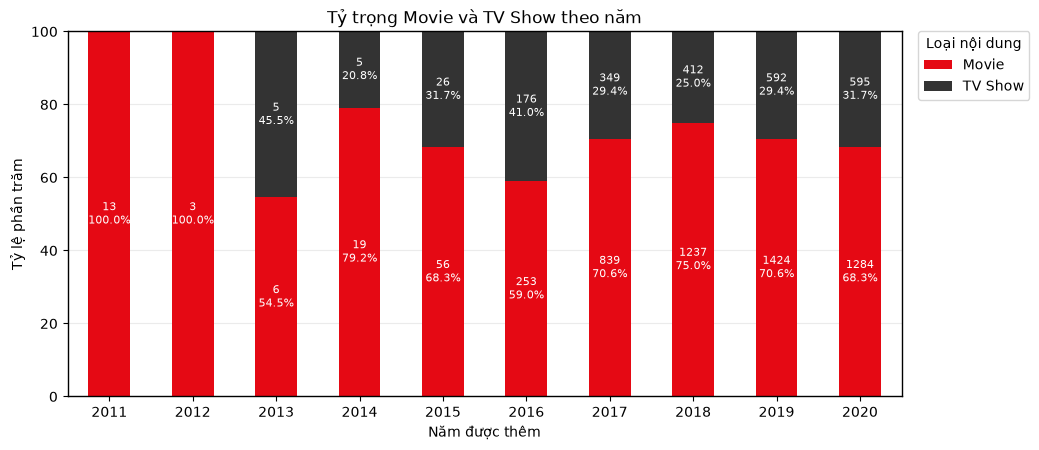

Movie thay đổi từ 2019 sang 2020: -140
TV Show thay đổi từ 2019 sang 2020: 3
Tổng title tăng từ 2016 đến 2019: 1587
Movie đóng góp: 1171 title
TV Show đóng góp: 416 title
Tỷ lệ đóng góp của Movie: 73.8 %


In [5]:
# Bước 1: Tạo bảng chéo giữa năm và loại nội dung.
type_by_year = pd.crosstab(titles["added_year"], titles["type"])
type_by_year = type_by_year[["Movie", "TV Show"]]

print("Số lượng theo năm:")
print(type_by_year)

# Bước 2: Tính tỷ lệ phần trăm trong từng năm.
year_total = type_by_year.sum(axis=1)
type_share = type_by_year.div(year_total, axis=0) * 100

print("Tỷ lệ theo năm:")
print(type_share.round(1))

# Bước 3: Vẽ biểu đồ cột chồng 100%.
fig, ax = plt.subplots(figsize=(12, 5))
type_share.plot(
    kind="bar",
    stacked=True,
    color=["#E50914", "#333333"],
    ax=ax
)

# Ghi cả số lượng và tỷ lệ phần trăm vào giữa từng phần của cột.
for position, year in enumerate(type_share.index):
    movie_percent = type_share.loc[year, "Movie"]
    tv_percent = type_share.loc[year, "TV Show"]
    movie_value = type_by_year.loc[year, "Movie"]
    tv_value = type_by_year.loc[year, "TV Show"]

    if movie_percent > 0:
        ax.text(
            position,
            movie_percent / 2,
            f"{movie_value}\n{movie_percent:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

    if tv_percent > 0:
        ax.text(
            position,
            movie_percent + tv_percent / 2,
            f"{tv_value}\n{tv_percent:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

plt.title("Tỷ trọng Movie và TV Show theo năm")
plt.xlabel("Năm được thêm")
plt.ylabel("Tỷ lệ phần trăm")
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20))
plt.xticks(rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(
    title="Loại nội dung",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
fig.subplots_adjust(right=0.82, bottom=0.15)
plt.show()

# Bước 4: So sánh thay đổi từ 2019 sang 2020.
movie_change = type_by_year.loc[2020, "Movie"] - type_by_year.loc[2019, "Movie"]
tv_change = type_by_year.loc[2020, "TV Show"] - type_by_year.loc[2019, "TV Show"]

# Bước 5: Phân rã mức tăng trong giai đoạn 2016-2019.
total_growth = year_total.loc[2019] - year_total.loc[2016]
movie_growth = type_by_year.loc[2019, "Movie"] - type_by_year.loc[2016, "Movie"]
tv_growth = type_by_year.loc[2019, "TV Show"] - type_by_year.loc[2016, "TV Show"]
movie_contribution = movie_growth / total_growth * 100

print("Movie thay đổi từ 2019 sang 2020:", movie_change)
print("TV Show thay đổi từ 2019 sang 2020:", tv_change)
print("Tổng title tăng từ 2016 đến 2019:", total_growth)
print("Movie đóng góp:", movie_growth, "title")
print("TV Show đóng góp:", tv_growth, "title")
print("Tỷ lệ đóng góp của Movie:", round(movie_contribution, 1), "%")

**Observation:** toàn giai đoạn có **5.134 Movie (70,4%)** và **2.160 TV Show (29,6%)**. Từ 2016 đến 2019, tổng additions tăng 1.587 title; Movie đóng góp 1.171 title, tương đương 73,8% mức tăng. Từ 2019 sang 2020, Movie giảm 140 title còn TV Show tăng 3 title. Vì vậy, mức giảm tổng additions năm 2020 chủ yếu đến từ Movie.  
**Caveat:** đây là phân rã đóng góp trong dataset, không chứng minh nguyên nhân kinh doanh và không phản ánh lượt xem.

## 6 Phân tích genre

**Câu hỏi:** Những genre nào xuất hiện trên nhiều title nhất?  
**Metric:** `COUNT DISTINCT show_id` theo genre.  
**Biểu đồ:** Bar chart ngang để dễ đọc tên genre dài.

genre
International Movies        2343
Dramas                      2013
Comedies                    1375
International TV Shows      1121
Documentaries                770
Independent Movies           666
Action & Adventure           663
TV Dramas                    625
Children & Family Movies     519
Romantic Movies              502
Name: show_id, dtype: int64


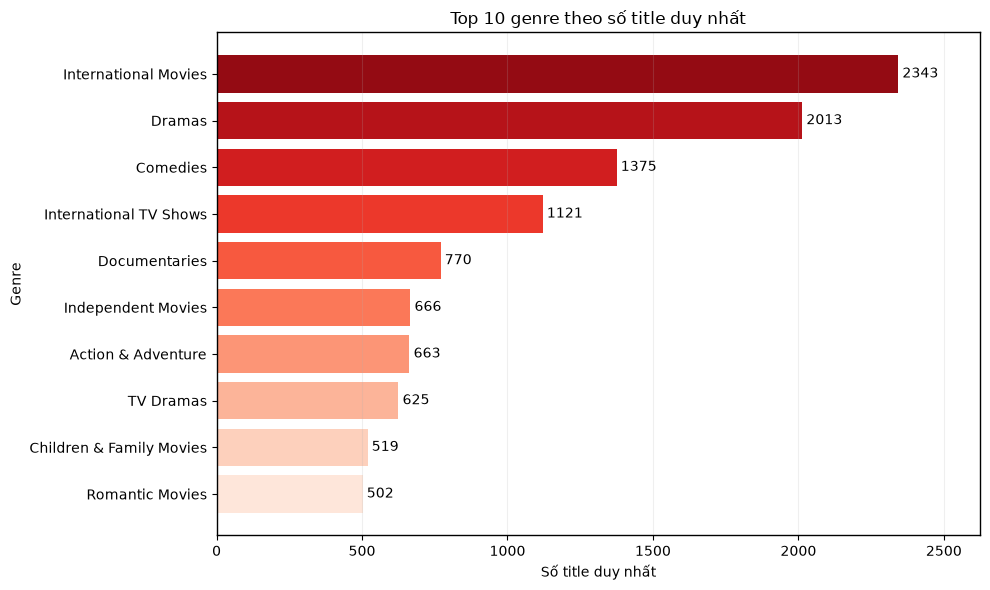

Genre đứng đầu: International Movies
Số title: 2343
Tỷ lệ trên tổng title: 32.1 %


In [6]:
# Bước 1: Đếm title duy nhất theo genre.
genre_counts = genres.groupby("genre")["show_id"].nunique()

# Bước 2: Chọn 10 genre cao nhất.
top_genres = genre_counts.sort_values(ascending=False).head(10)
print(top_genres)

# Bước 3: Đảo thứ tự để genre lớn nhất nằm trên cùng biểu đồ ngang.
top_genres_chart = top_genres.sort_values()

plt.figure(figsize=(10, 6))

# Giá trị thấp dùng màu nhạt, giá trị cao dùng màu đậm.
genre_colors = sns.color_palette("Reds", len(top_genres_chart))
bars = plt.barh(
    top_genres_chart.index,
    top_genres_chart.values,
    color=genre_colors
)
plt.bar_label(bars, padding=3)
plt.title("Top 10 genre theo số title duy nhất")
plt.xlabel("Số title duy nhất")
plt.ylabel("Genre")
plt.xlim(0, top_genres_chart.max() * 1.12)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

top_genre = top_genres.index[0]
top_genre_count = top_genres.iloc[0]
top_genre_share = top_genre_count / total_titles * 100

print("Genre đứng đầu:", top_genre)
print("Số title:", top_genre_count)
print("Tỷ lệ trên tổng title:", round(top_genre_share, 1), "%")

**Observation:** **International Movies** đứng đầu với **2.343 title (32,1%)**, tiếp theo là **Dramas (2.013)** và **Comedies (1.375)**.  
**Caveat:** một title có thể thuộc nhiều genre, vì vậy số lượng giữa các genre không cộng thành tổng title và tỷ lệ không cộng thành 100%.

## 7 Phân tích quốc gia

**Câu hỏi:** Những quốc gia nào được gắn với nhiều title nhất?  
**Metric:** `COUNT DISTINCT show_id` theo country.  
**Biểu đồ:** Bar chart ngang.

country
United States     3053
India              941
United Kingdom     685
Canada             386
France             333
Japan              264
South Korea        202
Spain              199
Germany            186
Mexico             148
Name: show_id, dtype: int64


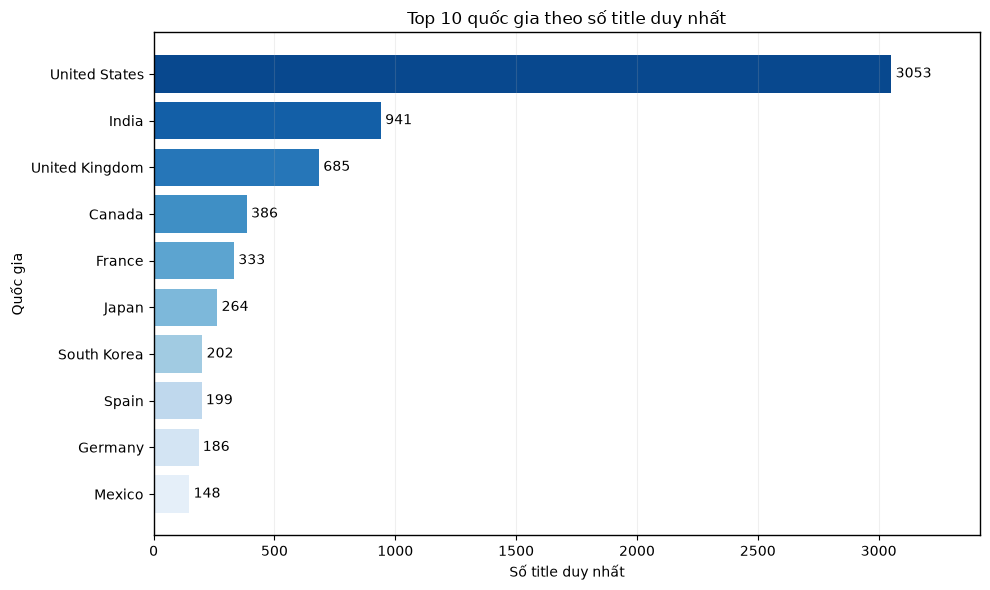

Số title có country: 6822
Số title thiếu country: 472
Độ bao phủ country: 93.5 %


In [7]:
# Bước 1: Đếm title duy nhất theo country.
country_counts = countries.groupby("country")["show_id"].nunique()

# Bước 2: Chọn 10 country cao nhất.
top_countries = country_counts.sort_values(ascending=False).head(10)
print(top_countries)

# Bước 3: Vẽ biểu đồ cột ngang.
top_countries_chart = top_countries.sort_values()

plt.figure(figsize=(10, 6))

# Giá trị thấp dùng màu nhạt, giá trị cao dùng màu đậm.
country_colors = sns.color_palette("Blues", len(top_countries_chart))
bars = plt.barh(
    top_countries_chart.index,
    top_countries_chart.values,
    color=country_colors
)
plt.bar_label(bars, padding=3)
plt.title("Top 10 quốc gia theo số title duy nhất")
plt.xlabel("Số title duy nhất")
plt.ylabel("Quốc gia")
plt.xlim(0, top_countries_chart.max() * 1.12)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Bước 4: Kiểm tra độ bao phủ của dữ liệu country.
titles_with_country = countries["show_id"].nunique()
missing_country = total_titles - titles_with_country
country_coverage = titles_with_country / total_titles * 100

print("Số title có country:", titles_with_country)
print("Số title thiếu country:", missing_country)
print("Độ bao phủ country:", round(country_coverage, 1), "%")

**Observation:** **United States** đứng đầu với **3.053 title**, tiếp theo là India (941) và United Kingdom (685). Có **472 title (6,5%)** thiếu country.  
**Caveat:** một title có thể liên quan nhiều quốc gia. Kết quả không phải thị phần sản xuất hoặc doanh thu theo quốc gia.

## 8 Phân tích rating

**Câu hỏi:** Cơ cấu rating thay đổi như thế nào theo năm?  
**Metric:** tỷ lệ title của từng rating trong tổng title có rating của cùng năm.  
**Biểu đồ:** Heatmap để so sánh đồng thời năm và rating.

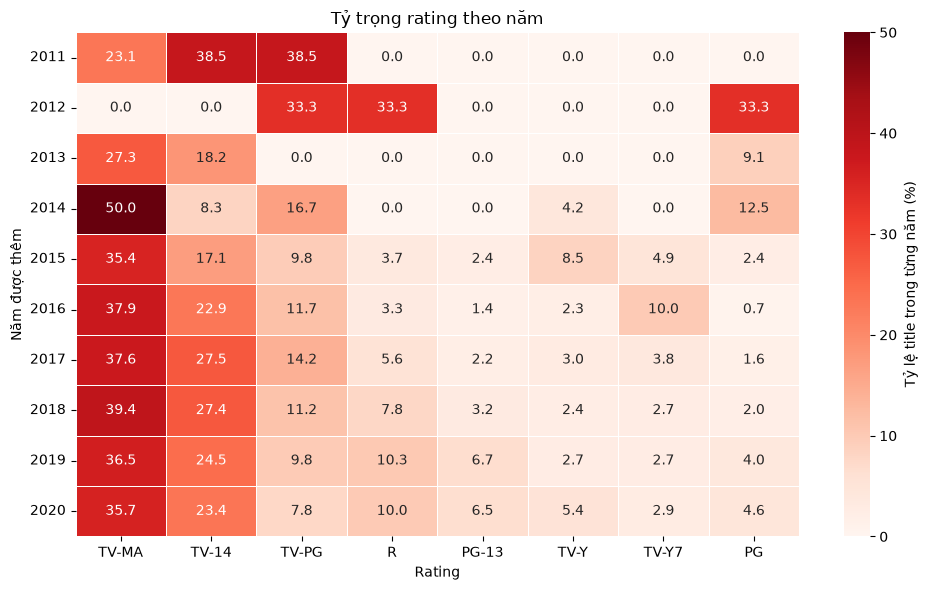

Số title có rating: 7290
Số title thuộc TV-MA hoặc TV-14: 4543
Tỷ lệ TV-MA và TV-14: 62.3 %
Số title thiếu rating: 4


In [8]:
# Bước 1: Chọn 8 rating xuất hiện nhiều nhất.
top_ratings = titles["rating"].value_counts().head(8).index

# Bước 2: Tạo bảng chéo năm x rating và chuẩn hóa theo từng năm.
rating_share = pd.crosstab(
    titles["added_year"],
    titles["rating"],
    normalize="index"
) * 100

rating_heatmap = rating_share[top_ratings]

# Bước 3: Vẽ heatmap bằng Seaborn.
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Tỷ lệ title trong từng năm (%)"}
)
plt.title("Tỷ trọng rating theo năm")
plt.xlabel("Rating")
plt.ylabel("Năm được thêm")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Bước 4: Tính tỷ trọng của hai rating lớn nhất.
known_rating = titles["rating"].notna().sum()
top_two_rating = titles["rating"].isin(["TV-MA", "TV-14"]).sum()
top_two_share = top_two_rating / known_rating * 100

print("Số title có rating:", known_rating)
print("Số title thuộc TV-MA hoặc TV-14:", top_two_rating)
print("Tỷ lệ TV-MA và TV-14:", round(top_two_share, 1), "%")
print("Số title thiếu rating:", titles["rating"].isna().sum())

**Observation:** **TV-MA và TV-14 chiếm 4.543/7.290 title có rating (62,3%)**.  
**Caveat:** hệ thống rating có thể khác nhau theo thị trường. Các năm đầu có ít title nên tỷ lệ dễ biến động; tỷ trọng rating không phản ánh sở thích người xem.

## 9 Insight đầy đủ

Mỗi insight gồm bốn phần:

- **Claim:** kết luận chính;
- **Evidence:** số liệu chứng minh;
- **Cách đọc:** ý nghĩa của bằng chứng;
- **Caveat:** giới hạn cần nêu để tránh kết luận quá mức.

In [9]:
# Tìm tháng có additions cao nhất để bổ sung insight cho phần mô hình.
peak_month_row = monthly.loc[monthly["monthly_additions"].idxmax()]
peak_month = pd.to_datetime(str(int(peak_month_row["date_key"])), format="%Y%m%d")

insights = pd.DataFrame([
    [
        "Xu hướng theo năm",
        "Catalog mở rộng mạnh và đạt đỉnh vào năm 2019.",
        "Năm 2016 có 429 title; năm 2019 có 2.016 title, tăng 1.587.",
        "Tốc độ bổ sung nội dung tăng rõ rệt trong giai đoạn 2016-2019.",
        "Đây là số title được thêm, không phải lượt xem hoặc số title được sản xuất."
    ],
    [
        "Thay đổi năm 2020",
        "Số title được thêm trong năm 2020 giảm nhẹ so với năm 2019.",
        "Năm 2020 có 1.879 title, giảm 137 title, tương đương 6,8%.",
        "Năm cuối của dữ liệu không tiếp tục mức tăng như giai đoạn trước.",
        "Dataset không có biến để kết luận nguyên nhân của mức giảm."
    ],
    [
        "Đóng góp theo type",
        "Movie là thành phần chính của giai đoạn tăng 2016-2019.",
        "Movie tăng 1.171/1.587 title, đóng góp 73,8%; TV Show tăng 416 title.",
        "Phần lớn mức tăng additions trong giai đoạn này đến từ Movie.",
        "Đóng góp không đồng nghĩa với quan hệ nhân quả."
    ],
    [
        "Mức giảm theo type",
        "Mức giảm năm 2020 chủ yếu đến từ Movie.",
        "Movie giảm 140 title trong khi TV Show tăng 3 title; tổng giảm 137.",
        "TV Show gần như ổn định, còn Movie giải thích gần như toàn bộ thay đổi ròng.",
        "Không được khẳng định Movie giảm vì COVID hoặc chiến lược Netflix."
    ],
    [
        "Genre",
        "International Movies là genre xuất hiện trên nhiều title nhất.",
        "International Movies có 2.343 title, chiếm 32,1%; Dramas có 2.013 và Comedies có 1.375.",
        "Nội dung có nhãn quốc tế và drama xuất hiện rộng trong catalog phân tích.",
        "Một title có nhiều genre nên tỷ lệ genre không cộng thành 100%."
    ],
    [
        "Country",
        "United States là quốc gia được gắn với nhiều title nhất.",
        "United States có 3.053 title; India 941; United Kingdom 685.",
        "United States đứng đầu với khoảng cách lớn so với các quốc gia tiếp theo.",
        "Có 472 title thiếu country và một title có thể liên quan nhiều quốc gia."
    ],
    [
        "Rating",
        "TV-MA và TV-14 chiếm phần lớn các title có rating.",
        "Hai rating này chiếm 4.543/7.290 title có rating, tương đương 62,3%.",
        "Catalog trong dataset tập trung nhiều ở hai nhóm rating này.",
        "Rating khác nhau theo thị trường và không phản ánh sở thích người xem."
    ],
    [
        "Theo tháng",
        f"{peak_month.strftime('%m/%Y')} là tháng có additions cao nhất.",
        f"Tháng này có {int(peak_month_row['monthly_additions'])} title được thêm.",
        "Đây là điểm cực đại quan sát được trong chuỗi 120 tháng.",
        "Một cực đại không đủ để kết luận nguyên nhân hoặc mùa vụ."
    ]
], columns=["Chủ đề", "Claim", "Evidence", "Cách đọc", "Caveat"])

insights

,Chủ đề,Claim,Evidence,Cách đọc,Caveat
0,Xu hướng theo năm,Catalog mở rộng mạnh và đạt đỉnh vào năm 2019.,Năm 2016 có 429 title; năm 2019 có 2.016 title...,Tốc độ bổ sung nội dung tăng rõ rệt trong giai...,"Đây là số title được thêm, không phải lượt xem..."
1,Thay đổi năm 2020,Số title được thêm trong năm 2020 giảm nhẹ so ...,"Năm 2020 có 1.879 title, giảm 137 title, tương...",Năm cuối của dữ liệu không tiếp tục mức tăng n...,Dataset không có biến để kết luận nguyên nhân ...
2,Đóng góp theo type,Movie là thành phần chính của giai đoạn tăng 2...,"Movie tăng 1.171/1.587 title, đóng góp 73,8%; ...",Phần lớn mức tăng additions trong giai đoạn nà...,Đóng góp không đồng nghĩa với quan hệ nhân quả.
3,Mức giảm theo type,Mức giảm năm 2020 chủ yếu đến từ Movie.,Movie giảm 140 title trong khi TV Show tăng 3 ...,"TV Show gần như ổn định, còn Movie giải thích ...",Không được khẳng định Movie giảm vì COVID hoặc...
4,Genre,International Movies là genre xuất hiện trên n...,"International Movies có 2.343 title, chiếm 32,...",Nội dung có nhãn quốc tế và drama xuất hiện rộ...,Một title có nhiều genre nên tỷ lệ genre không...
5,Country,United States là quốc gia được gắn với nhiều t...,United States có 3.053 title; India 941; Unite...,United States đứng đầu với khoảng cách lớn so ...,Có 472 title thiếu country và một title có thể...
6,Rating,TV-MA và TV-14 chiếm phần lớn các title có rat...,Hai rating này chiếm 4.543/7.290 title có rati...,Catalog trong dataset tập trung nhiều ở hai nh...,Rating khác nhau theo thị trường và không phản...
7,Theo tháng,11/2019 là tháng có additions cao nhất.,Tháng này có 255 title được thêm.,Đây là điểm cực đại quan sát được trong chuỗi ...,Một cực đại không đủ để kết luận nguyên nhân h...


## 10 Câu chuyện dữ liệu

### Storytelling là gì

Storytelling bằng dữ liệu là cách sắp xếp các insight theo một trình tự để người đọc hiểu được bối cảnh, thay đổi chính, nhóm đóng góp và giới hạn của kết luận. Storytelling không phải là tạo thêm một nguyên nhân mà dataset không chứng minh được.

### Câu chuyện của project

Trong phạm vi 2011-2020, số title được thêm vào Netflix tăng mạnh nhất trong giai đoạn 2016-2019. Catalog đi từ **429 title được thêm năm 2016** lên **2.016 title năm 2019**, tức tăng thêm 1.587 title. Movie là thành phần đóng góp chính cho mức tăng này với **1.171 title, tương đương 73,8%**, trong khi TV Show đóng góp 416 title.

Đến năm 2020, tổng additions giảm **137 title, tương đương 6,8%**, xuống còn 1.879. Khi phân rã theo loại nội dung, Movie giảm 140 title nhưng TV Show tăng 3 title. Vì vậy, mức giảm quan sát được trong năm 2020 chủ yếu đến từ Movie, còn TV Show gần như ổn định. Đây là kết luận mô tả đóng góp; dữ liệu không cho phép khẳng định nguyên nhân là COVID, chiến lược kinh doanh hoặc thay đổi nhu cầu người xem.

Xét cơ cấu toàn giai đoạn, Movie chiếm **70,4%** catalog phân tích. International Movies là genre xuất hiện nhiều nhất với 2.343 title; United States là country đứng đầu với 3.053 title; TV-MA và TV-14 chiếm 62,3% số title có rating. Các kết quả này mô tả cấu trúc catalog, không phản ánh lượt xem, doanh thu hoặc mức độ yêu thích.

Ở cấp độ tháng, **11/2019** là điểm cao nhất với 255 additions. Tuy nhiên, một tháng cao bất thường chưa đủ để kết luận nguyên nhân hoặc mùa vụ. Chuỗi monthly additions sẽ được dùng ở notebook mô hình để kiểm tra liệu Linear Regression có mô tả được xu hướng dài hạn hay không.

### Thông điệp chính

Catalog trong dataset mở rộng mạnh đến năm 2019 và Movie là thành phần đóng góp chính. Năm 2020 ghi nhận mức giảm chủ yếu từ Movie. Cấu trúc catalog nghiêng về Movie, nội dung quốc tế, United States và hai rating TV-MA, TV-14. Mọi kết luận chỉ áp dụng cho số title được thêm trong dataset.